# Análise de Vendas do Tesouro Direto

**Autora:** Sthefane  
**GitHub:** [coloque o link do seu perfil]  
**Data:** outubro/2026

---

## 1. Contexto

O Tesouro Direto é o programa do governo federal que permite a pessoas físicas comprar títulos públicos pela internet. Este projeto analisa o histórico de vendas do programa, disponibilizado como dado aberto pelo Tesouro Nacional.

## 2. Objetivo

Analisar o histórico de vendas do Tesouro Direto para identificar quais tipos de títulos concentram maior volume financeiro e maior quantidade negociada, avaliar a evolução das vendas ao longo do tempo e verificar possíveis padrões de sazonalidade.

## 3. Perguntas de negócio

1. Como são os dados? Colunas, tipos, nulos e período coberto.
2. Qual tipo de título mais vende, em valor e em quantidade?
3. Como as vendas evoluem por mês e por ano?
4. Existe sazonalidade? Algum mês se destaca?
5. Qual o valor médio por operação e como ele varia entre os títulos?

## 4. Fonte dos dados

- **Dataset:** Vendas do Tesouro Direto
- **Origem:** Tesouro Transparente, Tesouro Nacional
- **Link:** [Tesouro Transparente](https://www.tesourotransparente.gov.br/ckan/dataset)
- **Formato:** CSV
- **Período:** 2002 a 2026

## 5. Ferramentas

- Python
- pandas
- matplotlib
- Jupyter Notebook
- VS Code

## 6. Estrutura do notebook

1. Importação e leitura dos dados
2. Exploração inicial
3. Limpeza e tratamento
4. Análise e visualizações
5. Conclusões

In [ ]:
import pandas as pd

pd.options.display.float_format = "{:,.2f}".format

## 1. Importação e leitura dos dados

In [2]:
df = pd.read_csv(
    "../data/vendastesourodireto.csv",
    sep=";",
    decimal=",",
    encoding="latin1",
    dayfirst=True,
    parse_dates=["Data de Liquidacao da Venda"],
)

## 2. Exploração inicial

In [3]:
df.sample(10)

,Tipo Titulo,Vencimento do Titulo,Data de Liquidacao da Venda,PU,Quantidade,Valor
47835,Tesouro Prefixado,01/07/2006,2005-11-11,902.53,312.60,"282,130.68"
91445,Tesouro IPCA+,15/05/2019,2015-07-01,"2,074.77","8,975.45","18,621,952.55"
42013,Tesouro IPCA+ com Juros Semestrais,15/05/2045,2005-02-28,"1,045.23",49.00,"51,216.27"
40601,Tesouro IGPM+ com Juros Semestrais,01/03/2011,2003-11-07,"1,338.79",3.60,"4,819.63"
91071,Tesouro Prefixado com Juros Semestrais,01/01/2027,2016-08-10,909.13,933.45,"848,624.79"
32700,Tesouro Educa+,15/12/2047,2026-02-06,"1,229.10",144.97,"178,182.41"
48978,Tesouro Prefixado,01/10/2007,2006-08-23,863.69,132.40,"114,352.09"
43667,Tesouro Prefixado,01/01/2007,2005-03-09,744.53,340.60,"253,585.83"
91980,Tesouro Prefixado,01/01/2021,2015-11-30,479.49,"13,442.70","6,445,707.16"
74421,Tesouro Prefixado com Juros Semestrais,01/01/2021,2010-04-09,881.52,266.20,"234,659.95"


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100961 entries, 0 to 100960
Data columns (total 6 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   Tipo Titulo                  100961 non-null  str           
 1   Vencimento do Titulo         100961 non-null  str           
 2   Data de Liquidacao da Venda  100961 non-null  datetime64[us]
 3   PU                           100961 non-null  float64       
 4   Quantidade                   100961 non-null  float64       
 5   Valor                        100961 non-null  float64       
dtypes: datetime64[us](1), float64(3), str(2)
memory usage: 4.6 MB


In [5]:
df.isna().sum()

Tipo Titulo                    0
Vencimento do Titulo           0
Data de Liquidacao da Venda    0
PU                             0
Quantidade                     0
Valor                          0
dtype: int64

## 3. Limpeza e tratamento

In [6]:
df = df.rename(
    columns={
        "Tipo Titulo": "tipo_titulo",
        "Vencimento do Titulo": "vencimento_titulo",
        "Data de Liquidacao da Venda": "data_liquidacao",
        "PU": "pu",
        "Quantidade": "quantidade",
        "Valor": "valor",
    }
)

In [7]:
df["vencimento_titulo"] = pd.to_datetime(
    df["vencimento_titulo"], dayfirst=True, errors="coerce"
)

In [8]:
df.isna().sum()

tipo_titulo          0
vencimento_titulo    0
data_liquidacao      0
pu                   0
quantidade           0
valor                0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

## 4. Análise e visualizações

### 4.1 Qual tipo de título mais vende?

In [10]:
# Em valor
mais_vendas_valor = (
    df.groupby("tipo_titulo")["valor"].sum().sort_values(ascending=False).reset_index()
)
display(mais_vendas_valor)

,tipo_titulo,valor
0,Tesouro Selic,"244,085,736,260.20"
1,Tesouro IPCA+,"138,879,867,861.02"
2,Tesouro Prefixado,"71,796,925,591.56"
3,Tesouro IPCA+ com Juros Semestrais,"36,809,920,868.94"
4,Tesouro RendA+,"15,117,693,307.37"
5,Tesouro Prefixado com Juros Semestrais,"13,347,309,870.13"
6,Tesouro Reserva,"8,363,193,010.67"
7,Tesouro Educa+,"4,213,953,013.08"
8,Tesouro IGPM+ com Juros Semestrais,"316,239,066.96"


In [11]:
# Em quantidade
mais_vendas_quantidade = (
    df.groupby("tipo_titulo")["quantidade"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
display(mais_vendas_quantidade)

,tipo_titulo,quantidade
0,Tesouro Reserva,"779,904,083.55"
1,Tesouro Prefixado,"113,580,854.72"
2,Tesouro IPCA+,"73,705,605.40"
3,Tesouro RendA+,"47,734,761.81"
4,Tesouro Selic,"18,995,685.86"
5,Tesouro Prefixado com Juros Semestrais,"14,341,788.71"
6,Tesouro IPCA+ com Juros Semestrais,"10,599,247.55"
7,Tesouro Educa+,"1,514,616.10"
8,Tesouro IGPM+ com Juros Semestrais,"197,363.40"


### 4.2 Como as vendas evoluem por mês e por ano?

In [12]:
df["ano_mes"] = df["data_liquidacao"].dt.to_period("M")
vendas_por_mes = df.groupby("ano_mes")["valor"].sum().reset_index()


Text(0, 0.5, 'Valor vendido')

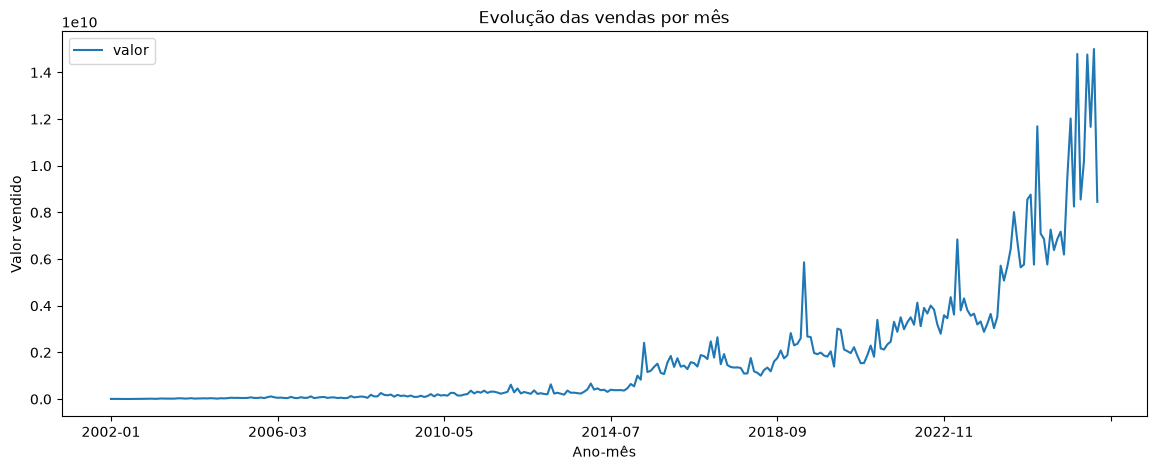

In [13]:
vendas_por_mes["ano_mes"] = vendas_por_mes["ano_mes"].astype(str)

ax = vendas_por_mes.plot(
    x="ano_mes",
    y="valor",
    kind="line",
    figsize=(14, 5),
    title="Evolução das vendas por mês",
)

ax.set_xlabel("Ano-mês")
ax.set_ylabel("Valor vendido")

In [14]:
df["ano"] = df["data_liquidacao"].dt.year
vendas_por_ano = df.groupby("ano")["valor"].sum().reset_index()

Text(0, 0.5, 'Valor vendido')

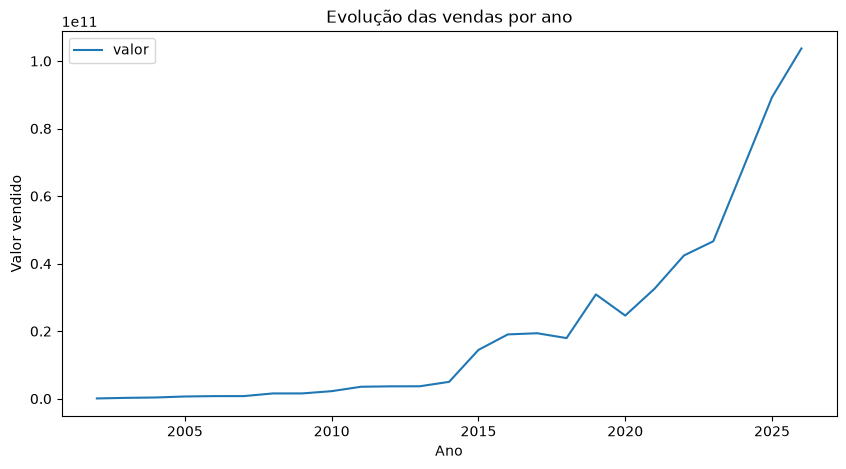

In [15]:
ax = vendas_por_ano.plot(
    x="ano",
    y="valor",
    kind="line",
    figsize=(10, 5),
    title="Evolução das vendas por ano",
)

ax.set_xlabel("Ano")
ax.set_ylabel("Valor vendido")

In [16]:
df["mes"] = df["data_liquidacao"].dt.month
sazonalidade = df.groupby("mes")["valor"].sum().reset_index()

<Axes: title={'center': 'Vendas por mês'}, xlabel='mes'>

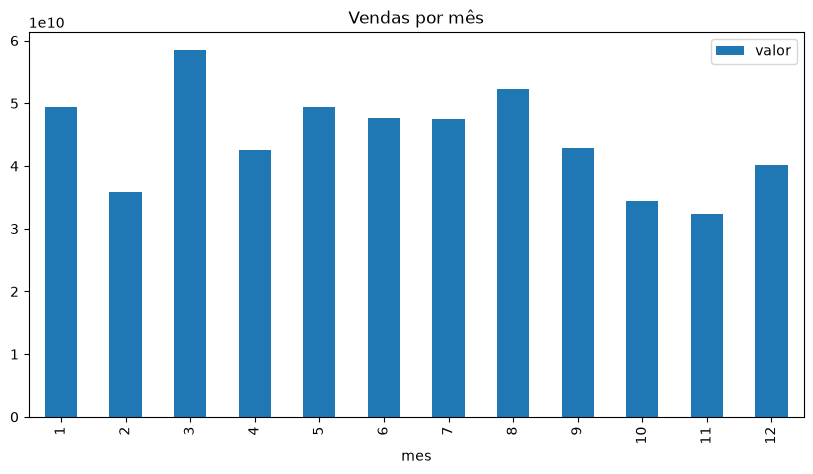

In [17]:
sazonalidade.plot(
    x="mes", y="valor", kind="bar", figsize=(10, 5), title="Vendas por mês"
)

In [18]:
valor_medio_operacao = df["valor"].mean()
valor_medio_operacao

np.float64(5278581.222946782)

In [19]:
valor_medio_por_titulo = (
    df.groupby("tipo_titulo")["valor"].mean().sort_values(ascending=False).reset_index()
)

display(valor_medio_por_titulo)

,tipo_titulo,valor
0,Tesouro Reserva,"50,995,079.33"
1,Tesouro Selic,"23,590,000.61"
2,Tesouro IPCA+,"9,556,173.39"
3,Tesouro Prefixado,"4,115,144.47"
4,Tesouro RendA+,"2,076,606.22"
5,Tesouro IPCA+ com Juros Semestrais,"1,564,582.01"
6,Tesouro Prefixado com Juros Semestrais,"1,394,994.76"
7,Tesouro Educa+,"309,508.12"
8,Tesouro IGPM+ com Juros Semestrais,"70,589.08"


<Axes: title={'center': 'Valor médio por operação por tipo de título'}, xlabel='tipo_titulo'>

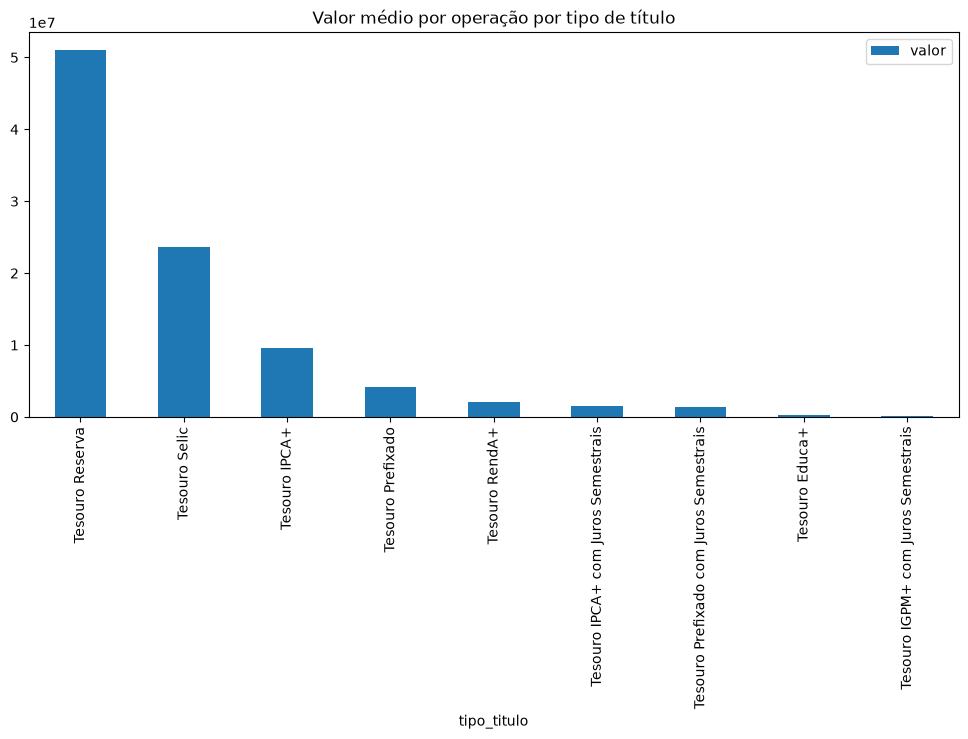

In [20]:
valor_medio_por_titulo.plot(
    x="tipo_titulo",
    y="valor",
    kind="bar",
    figsize=(12, 5),
    title="Valor médio por operação por tipo de título",
)

## 5. Conclusão

A análise das vendas do Tesouro Direto mostrou que a base possui registros históricos de operações de venda, com informações sobre tipo de título, data de liquidação, quantidade, preço unitário e valor vendido.

Em relação às vendas por tipo de título, o Tesouro Selic apresentou o maior volume financeiro vendido no período analisado. Já em quantidade vendida, o Tesouro Reserva foi o título com maior destaque. Isso mostra que o título com maior valor total vendido não necessariamente é o mesmo que possui maior quantidade negociada.

Na análise temporal, foi possível observar uma tendência de crescimento das vendas ao longo dos anos, principalmente nos períodos mais recentes. O gráfico mensal também mostra aumento expressivo no volume vendido nos últimos anos, com alguns picos de venda em determinados meses.

Na análise de sazonalidade, os valores vendidos variam entre os meses do ano. O mês 3 apresentou o maior volume de vendas, enquanto os meses 10 e 11 ficaram entre os menores valores. Isso sugere indícios de sazonalidade nas vendas, embora uma análise mais aprofundada fosse necessária para confirmar esse padrão.

Por fim, o valor médio por operação variou bastante entre os tipos de título. O Tesouro Reserva apresentou o maior valor médio por operação, seguido pelo Tesouro Selic e pelo Tesouro IPCA+. Já títulos como Tesouro Educa+ e Tesouro IGPM+ com Juros Semestrais apresentaram valores médios menores.

De forma geral, o projeto permitiu identificar quais títulos concentram maior valor financeiro e maior quantidade negociada, analisar a evolução das vendas ao longo do tempo e observar possíveis padrões mensais nas vendas do Tesouro Direto.